In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/scoring"
    !pip install -q interpret shap fairlearn lightgbm xgboost
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, PROJECT_ROOT)
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")

# Phase 4: Fairness Analysis

## 4.1 Define candidate fairness attributes

In [2]:
import pandas as pd, numpy as np, joblib, warnings, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
from sklearn.metrics import roc_curve, roc_auc_score, auc
from src.evaluate import compute_metrics
from src.fairness import compute_fairness_metrics, bin_continuous, disparate_impact_ratio

# Load raw data (pre-encoding) for fairness attributes
from src.data import load_raw, define_target, temporal_split

df_raw = load_raw(DATA_DIR)
df = define_target(df_raw)
_, df_test_raw = temporal_split(df, date_col="issue_d", train_end="Jul-2015", test_end="Dec-2018")

# Load processed test data and best model
# X_test_raw.csv is the raw-feature CSV produced by notebook 01
X_test = pd.read_csv(os.path.join(DATA_DIR, "processed", "X_test_raw.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "processed", "y_test.csv")).squeeze()

# Use EBM (top 10) as the primary model for fairness analysis — glass-box, interpretable
# ebm_top10.pkl is a sklearn Pipeline (ColumnTransformer + EBM) accepting raw DataFrames
top10 = pd.read_csv(os.path.join(REPORTS_DIR, "top10_features.csv")).squeeze().tolist()
ebm = joblib.load(os.path.join(MODELS_DIR, "ebm_top10.pkl"))
X_test_10 = X_test[top10]
y_prob = ebm.predict_proba(X_test_10)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
opt_t = thresholds[np.argmax(tpr - fpr)]
y_pred = (y_prob >= opt_t).astype(int)
print(f"Using EBM (top 10) with threshold={opt_t:.4f}")
print(f"Test set: {len(y_test):,} samples, positive rate: {y_test.mean()*100:.1f}%")

# Define candidate fairness attributes from raw test data
# These columns exist in the pre-encoded dataset
candidates = {
    "income_bracket": bin_continuous(df_test_raw["annual_inc"].reset_index(drop=True), bins=3, labels=["Low", "Mid", "High"]),
    "home_ownership": df_test_raw["home_ownership"].reset_index(drop=True),
    "dti_bracket": bin_continuous(df_test_raw["dti"].reset_index(drop=True).fillna(df_test_raw["dti"].median()), bins=3, labels=["Low", "Mid", "High"]),
    "purpose": df_test_raw["purpose"].reset_index(drop=True),
    "emp_length": df_test_raw["emp_length"].reset_index(drop=True).fillna("Unknown"),
}

print(f"\nCandidate fairness attributes: {list(candidates.keys())}")
for name, attr in candidates.items():
    print(f"  {name}: {attr.nunique()} groups — {dict(attr.value_counts().head(5))}")

Using EBM (top 10) with threshold=0.1598
Test set: 1,096,128 samples, positive rate: 20.9%

Candidate fairness attributes: ['income_bracket', 'home_ownership', 'dti_bracket', 'purpose', 'emp_length']
  income_bracket: 3 groups — {'Mid': np.int64(366882), 'Low': np.int64(365376), 'High': np.int64(363870)}
  home_ownership: 5 groups — {'MORTGAGE': np.int64(533866), 'RENT': np.int64(430581), 'OWN': np.int64(131056), 'ANY': np.int64(621), 'NONE': np.int64(4)}
  dti_bracket: 3 groups — {'Low': np.int64(365639), 'Mid': np.int64(365475), 'High': np.int64(365014)}
  purpose: 14 groups — {'debt_consolidation': np.int64(612488), 'credit_card': np.int64(239718), 'home_improvement': np.int64(78885), 'other': np.int64(75066), 'major_purchase': np.int64(26509)}


  emp_length: 12 groups — {'10+ years': np.int64(363116), '2 years': np.int64(100654), '< 1 year': np.int64(91527), '3 years': np.int64(89310), 'Unknown': np.int64(77383)}


## 4.2 Compute fairness metrics per attribute


income_bracket:
  Demographic parity diff: 0.2281
  Equalized odds diff:     0.2207
  Disparate impact (High): 0.731
  Disparate impact (Mid): 0.999
  Disparate impact (Low): 1.269



home_ownership:
  Demographic parity diff: 0.1288
  Equalized odds diff:     0.7092
  Disparate impact (MORTGAGE): 0.875
  Disparate impact (ANY): 0.915
  Disparate impact (OWN): 1.048
  Disparate impact (RENT): 1.140
  Disparate impact (NONE): 1.179



dti_bracket:
  Demographic parity diff: 0.3165
  Equalized odds diff:     0.2997
  Disparate impact (Low): 0.655
  Disparate impact (Mid): 0.945
  Disparate impact (High): 1.401



purpose:
  Demographic parity diff: 0.6853
  Equalized odds diff:     0.7343
  Disparate impact (car): 0.742
  Disparate impact (vacation): 0.743
  Disparate impact (home_improvement): 0.806
  Disparate impact (credit_card): 0.808
  Disparate impact (major_purchase): 0.845
  Disparate impact (medical): 0.870
  Disparate impact (wedding): 0.885
  Disparate impact (other): 0.955
  Disparate impact (moving): 0.968
  Disparate impact (renewable_energy): 1.009
  Disparate impact (debt_consolidation): 1.120
  Disparate impact (house): 1.149
  Disparate impact (small_business): 1.165
  Disparate impact (educational): 2.359



emp_length:
  Demographic parity diff: 0.0973
  Equalized odds diff:     0.0876
  Disparate impact (10+ years): 0.939
  Disparate impact (9 years): 0.977
  Disparate impact (8 years): 0.981
  Disparate impact (7 years): 0.988
  Disparate impact (6 years): 0.996
  Disparate impact (2 years): 1.016
  Disparate impact (3 years): 1.017
  Disparate impact (5 years): 1.019
  Disparate impact (4 years): 1.026
  Disparate impact (< 1 year): 1.029
  Disparate impact (1 year): 1.038
  Disparate impact (Unknown): 1.169

=== Fairness Summary ===
                Demographic Parity Diff  Equalized Odds Diff  Max DI Deviation
income_bracket                 0.228092             0.220718          0.269298
home_ownership                 0.128839             0.709167          0.179396
dti_bracket                    0.316512             0.299718          0.401282
purpose                        0.685324             0.734262          1.358791
emp_length                     0.097266             0.087616    

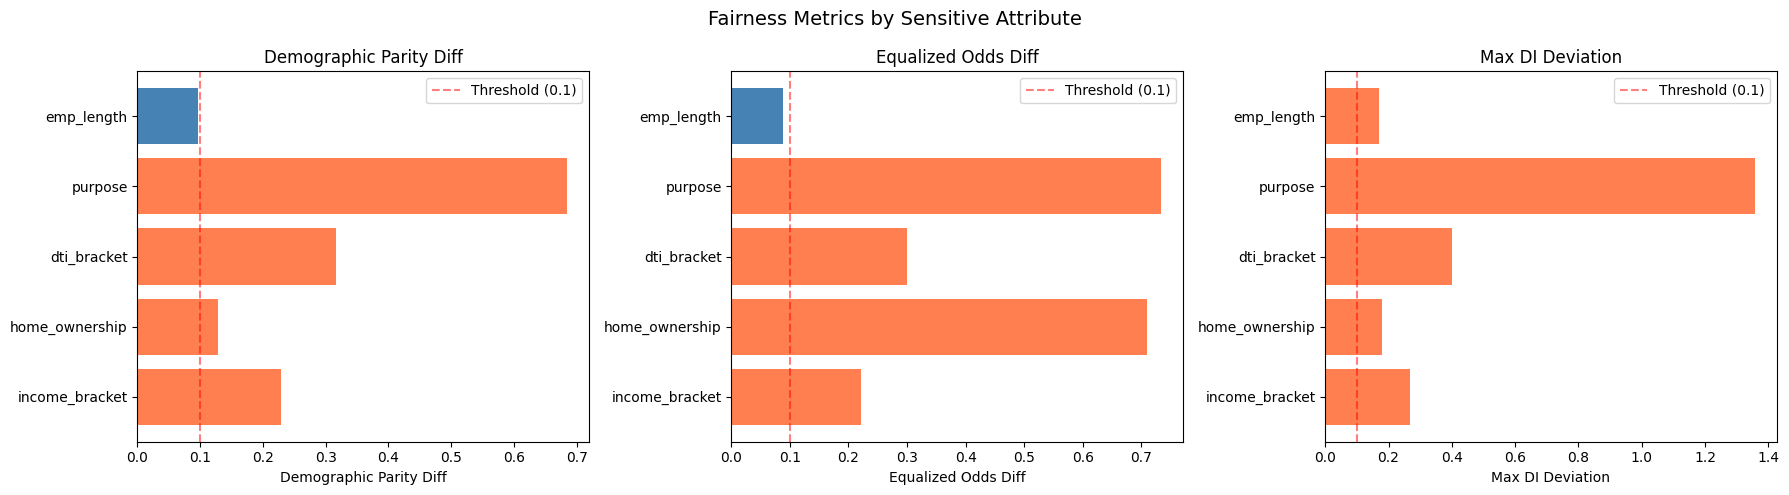

In [3]:
# Compute fairness metrics for each candidate attribute
fairness_results = {}
for name, attr in candidates.items():
    try:
        metrics = compute_fairness_metrics(y_test.values, y_pred, attr.values)
        fairness_results[name] = metrics
        print(f"\n{name}:")
        print(f"  Demographic parity diff: {metrics['demographic_parity_diff']:.4f}")
        print(f"  Equalized odds diff:     {metrics['equalized_odds_diff']:.4f}")
        di = metrics['disparate_impact']
        for g, v in sorted(di.items(), key=lambda x: x[1]):
            print(f"  Disparate impact ({g}): {v:.3f}")
    except Exception as e:
        print(f"\n{name}: ERROR — {e}")

# Summary table
summary = pd.DataFrame({
    name: {
        "Demographic Parity Diff": m["demographic_parity_diff"],
        "Equalized Odds Diff": m["equalized_odds_diff"],
        "Max DI Deviation": max(abs(v - 1) for v in m["disparate_impact"].values()),
    }
    for name, m in fairness_results.items()
}).T
print("\n=== Fairness Summary ===")
print(summary.to_string())

# Visualization: bar chart of fairness metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(summary.columns):
    ax = axes[i]
    colors = ["coral" if v > 0.1 else "steelblue" for v in summary[metric]]
    ax.barh(summary.index, summary[metric], color=colors)
    ax.axvline(x=0.1, color="red", linestyle="--", alpha=0.5, label="Threshold (0.1)")
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.legend()
plt.suptitle("Fairness Metrics by Sensitive Attribute", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "fairness_metrics_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4.3 SHAP value distributions across groups

Most impactful attribute: purpose

Mean |SHAP| by purpose group (XGBoost, top 10 features):

  car (n=42):
    int_rate: 0.5567
    term: 0.1488
    acc_open_past_24mths: 0.1340
    annual_inc: 0.1319
    fico: 0.1191

  credit_card (n=1109):
    int_rate: 0.5023
    term: 0.1630
    acc_open_past_24mths: 0.1418
    annual_inc: 0.1139
    dti: 0.0970

  debt_consolidation (n=2797):
    int_rate: 0.4578
    term: 0.1735
    acc_open_past_24mths: 0.1450
    annual_inc: 0.1123
    dti: 0.0918

  home_improvement (n=368):
    int_rate: 0.4794
    term: 0.1673
    acc_open_past_24mths: 0.1366
    annual_inc: 0.1174
    loan_amnt: 0.1044

  house (n=37):
    int_rate: 0.5018
    term: 0.1740
    acc_open_past_24mths: 0.1378
    loan_amnt: 0.1134
    annual_inc: 0.1083

  major_purchase (n=125):
    int_rate: 0.4915
    term: 0.1741
    acc_open_past_24mths: 0.1366
    annual_inc: 0.1174
    loan_amnt: 0.1076

  medical (n=76):
    int_rate: 0.3986
    term: 0.1678
    loan_amnt: 0.1451
    a

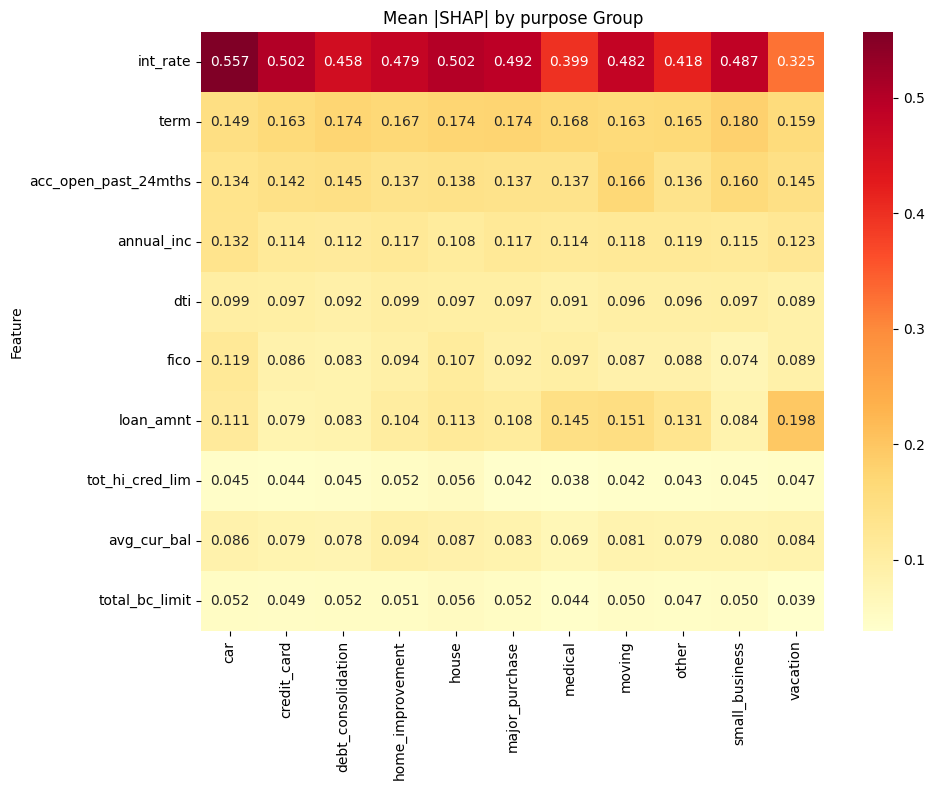

In [4]:
# SHAP values by group — using XGBoost (TreeExplainer doesn't support EBM)
import shap

# xgb_top10.pkl is a Pipeline; pass the clf step to TreeExplainer,
# and preprocess the input data through the pipeline's 'pre' step first.
xgb_10 = joblib.load(os.path.join(MODELS_DIR, "xgb_top10.pkl"))
xgb_clf = xgb_10.named_steps["clf"]
xgb_pre = xgb_10.named_steps["pre"]

explainer = shap.TreeExplainer(xgb_clf)
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_test_10), size=min(5000, len(X_test_10)), replace=False)
X_sample_raw = X_test_10.iloc[sample_idx]
X_sample_pre = xgb_pre.transform(X_sample_raw)
shap_values = explainer.shap_values(X_sample_pre)
# shap_values has shape (n, n_preprocessed_features); use only the first len(top10) dims
# (term gets OHE'd into 2; we collapse back to top10 names for display)
# Build a mapping: sum OHE columns for 'term' back into a single 'term' column
feat_names_pre = list(xgb_pre.get_feature_names_out())
# Create a (n_samples, 10) matrix with SHAP summed over OHE groups
shap_top10 = np.zeros((shap_values.shape[0], len(top10)))
for j, feat in enumerate(top10):
    # Find all preprocessed columns that correspond to this feature
    cols = [k for k, name in enumerate(feat_names_pre)
            if name == f"num__{feat}" or name == f"count__{feat}" or name == f"pct__{feat}"
            or name.startswith(f"cat__{feat}_")]
    if cols:
        shap_top10[:, j] = shap_values[:, cols].sum(axis=1)

# Pick the attribute with highest demographic parity difference
most_unfair = summary["Demographic Parity Diff"].abs().idxmax()
print(f"Most impactful attribute: {most_unfair}")

attr_sample = candidates[most_unfair].iloc[sample_idx]
groups = sorted(attr_sample.dropna().unique())

# Mean |SHAP| per feature per group
print(f"\nMean |SHAP| by {most_unfair} group (XGBoost, top 10 features):")
shap_by_group = {}
for g in groups:
    mask = attr_sample == g
    if mask.sum() < 10:
        continue
    mean_shap = pd.Series(np.abs(shap_top10[mask.values]).mean(axis=0), index=top10)
    shap_by_group[g] = mean_shap
    print(f"\n  {g} (n={mask.sum()}):")
    for feat, val in mean_shap.sort_values(ascending=False).head(5).items():
        print(f"    {feat}: {val:.4f}")

# SHAP divergence heatmap
shap_group_df = pd.DataFrame(shap_by_group)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(shap_group_df, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
ax.set_title(f"Mean |SHAP| by {most_unfair} Group")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, f"shap_divergence_{most_unfair}.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4.4 Proxy leakage checks

Proxy leakage check: correlations between model features and sensitive attributes



Absolute correlations (features × sensitive attributes):
                      income_bracket  home_ownership  dti_bracket  purpose  emp_length
int_rate                       0.059           0.081        0.121    0.082       0.012
term                           0.025           0.096        0.023    0.066       0.031
acc_open_past_24mths           0.039           0.079        0.045    0.014       0.028
annual_inc                     0.185           0.071        0.036    0.000       0.045
dti                              NaN             NaN          NaN      NaN         NaN
fico                           0.052           0.094        0.008    0.054       0.012
loan_amnt                      0.245           0.168        0.000    0.156       0.061
tot_hi_cred_lim                0.300           0.497        0.004    0.029       0.075
avg_cur_bal                      NaN             NaN          NaN      NaN         NaN
total_bc_limit                 0.223           0.134        0.020    0.07

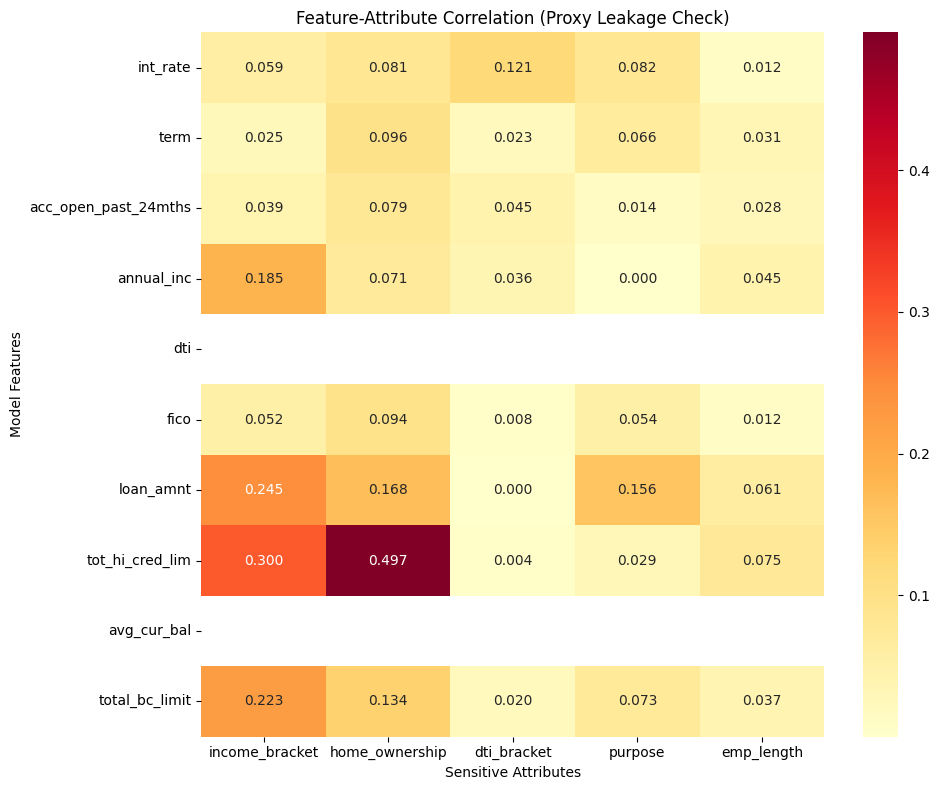

In [5]:
# Proxy leakage: check correlations between top 10 features and sensitive attributes
print("Proxy leakage check: correlations between model features and sensitive attributes\n")

# Encode sensitive attributes numerically for correlation
from sklearn.preprocessing import LabelEncoder

proxy_results = {}
for attr_name, attr_vals in candidates.items():
    le = LabelEncoder()
    attr_encoded = le.fit_transform(attr_vals.astype(str))
    correlations = {}
    for feat in top10:
        if feat in X_test.columns:
            r = np.corrcoef(X_test[feat].values, attr_encoded)[0, 1]
            correlations[feat] = abs(r)
    proxy_results[attr_name] = correlations

proxy_df = pd.DataFrame(proxy_results)
print("Absolute correlations (features × sensitive attributes):")
print(proxy_df.round(3).to_string())

# Flag potential proxies (|r| > 0.3)
print("\nPotential proxy features (|r| > 0.3):")
flagged = False
for attr in proxy_df.columns:
    for feat in proxy_df.index:
        if proxy_df.loc[feat, attr] > 0.3:
            print(f"  {feat} → {attr}: r={proxy_df.loc[feat, attr]:.3f}")
            flagged = True
if not flagged:
    print("  None found — no strong proxies detected.")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(proxy_df, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
ax.set_title("Feature-Attribute Correlation (Proxy Leakage Check)")
ax.set_ylabel("Model Features")
ax.set_xlabel("Sensitive Attributes")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "proxy_leakage_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4.5 Iterate: keep informative attributes, drop uninformative

In [6]:
# Iterate: keep attributes with meaningful disparities, drop uninformative ones
THRESHOLD = 0.05  # minimum demographic parity diff to be considered meaningful

informative = summary[summary["Demographic Parity Diff"].abs() > THRESHOLD].index.tolist()
uninformative = summary[summary["Demographic Parity Diff"].abs() <= THRESHOLD].index.tolist()

print(f"Informative attributes (DPD > {THRESHOLD}): {informative}")
print(f"Uninformative attributes (DPD <= {THRESHOLD}): {uninformative}")
print(f"\nKeeping {len(informative)} attributes for detailed analysis.")

Informative attributes (DPD > 0.05): ['income_bracket', 'home_ownership', 'dti_bracket', 'purpose', 'emp_length']
Uninformative attributes (DPD <= 0.05): []

Keeping 5 attributes for detailed analysis.


## 4.6 Visualizations: per-group ROC, SHAP divergence, fairness tables

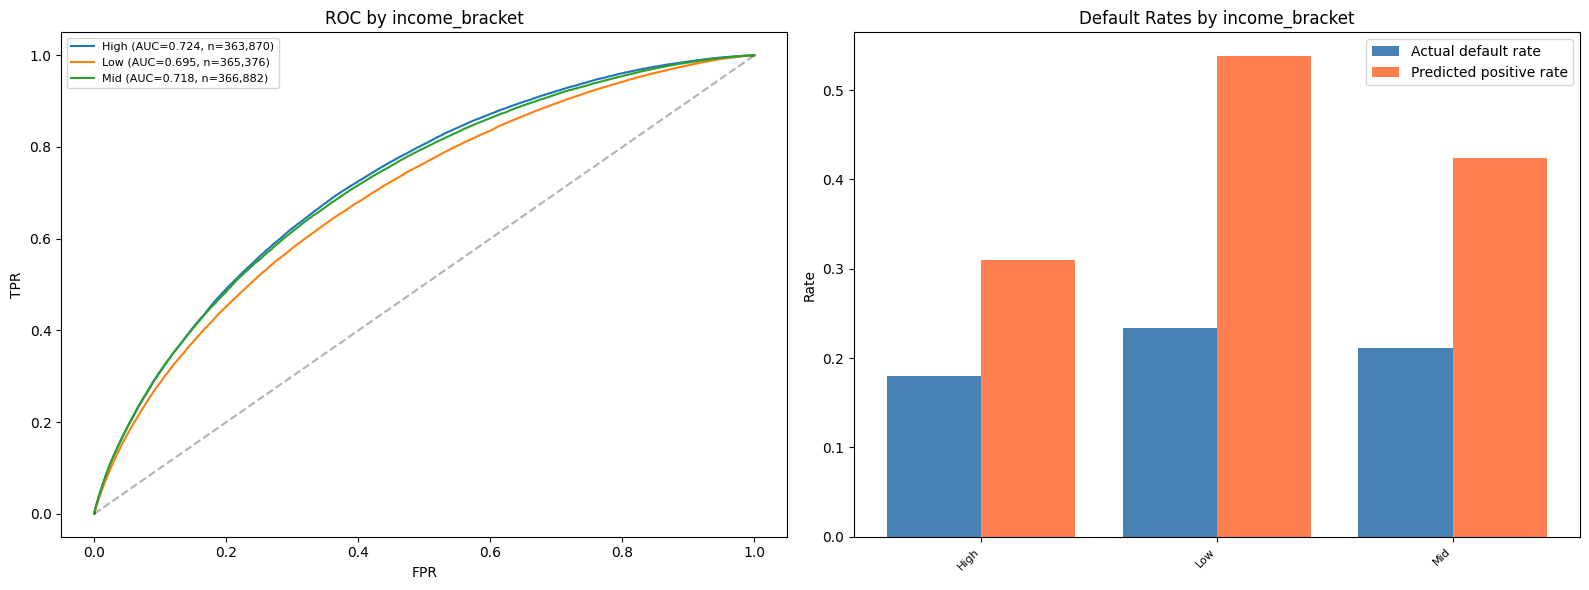

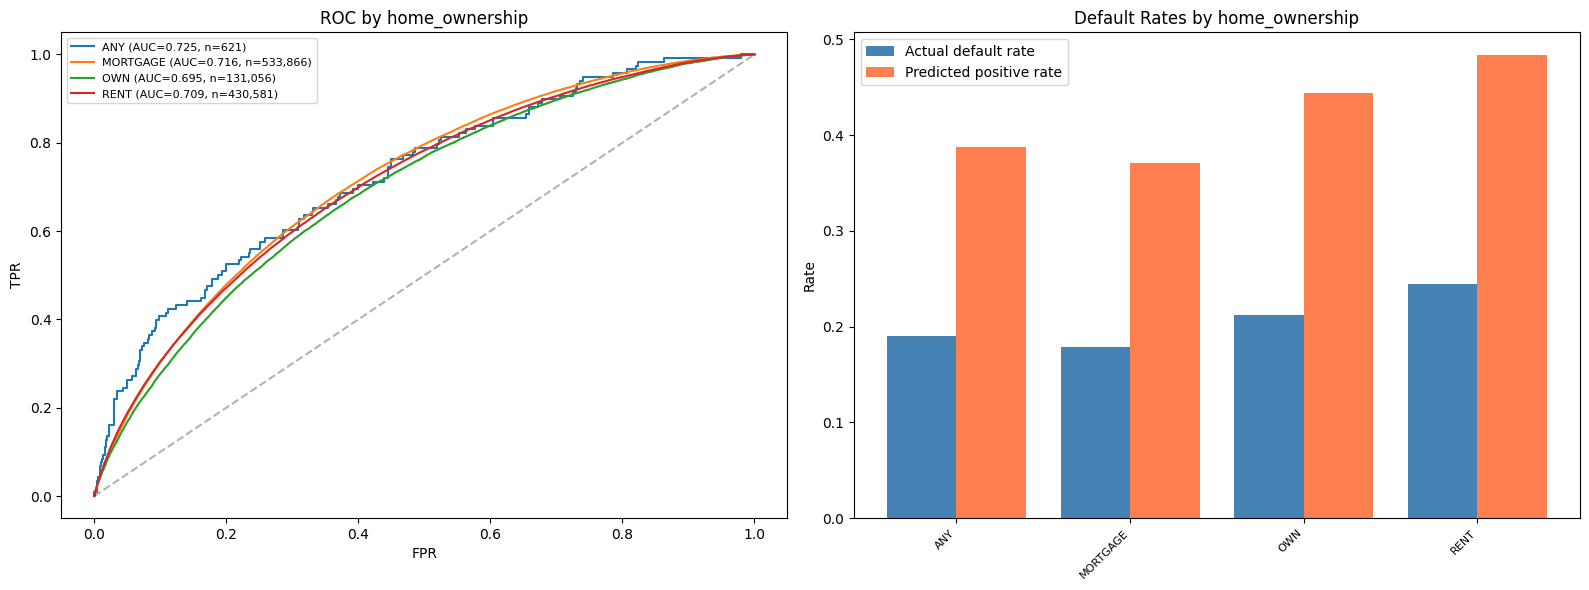

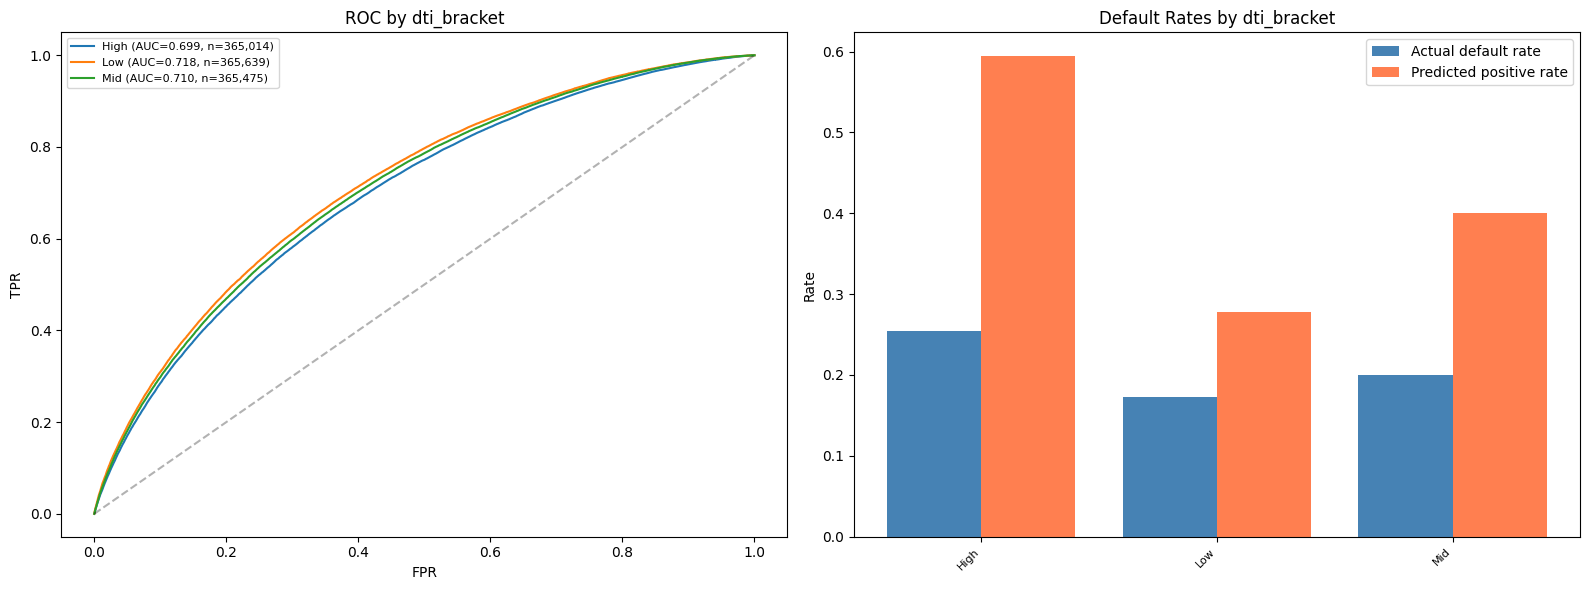

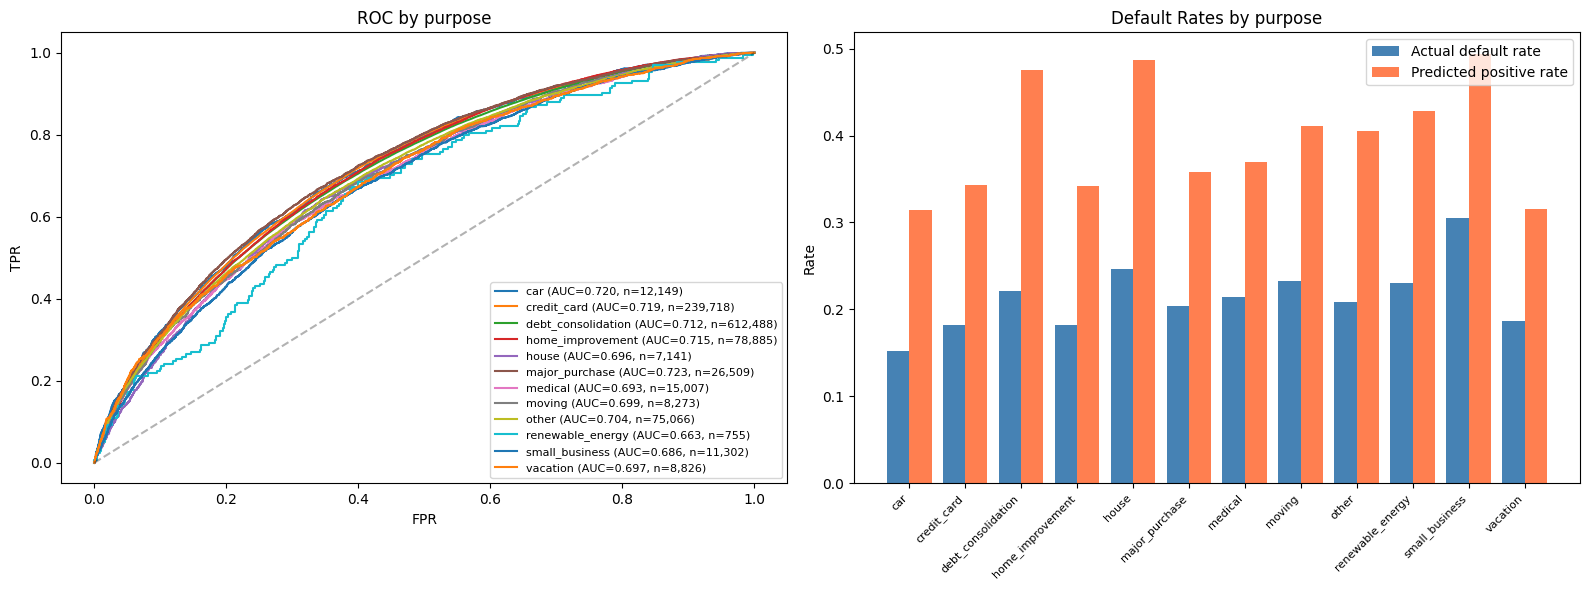

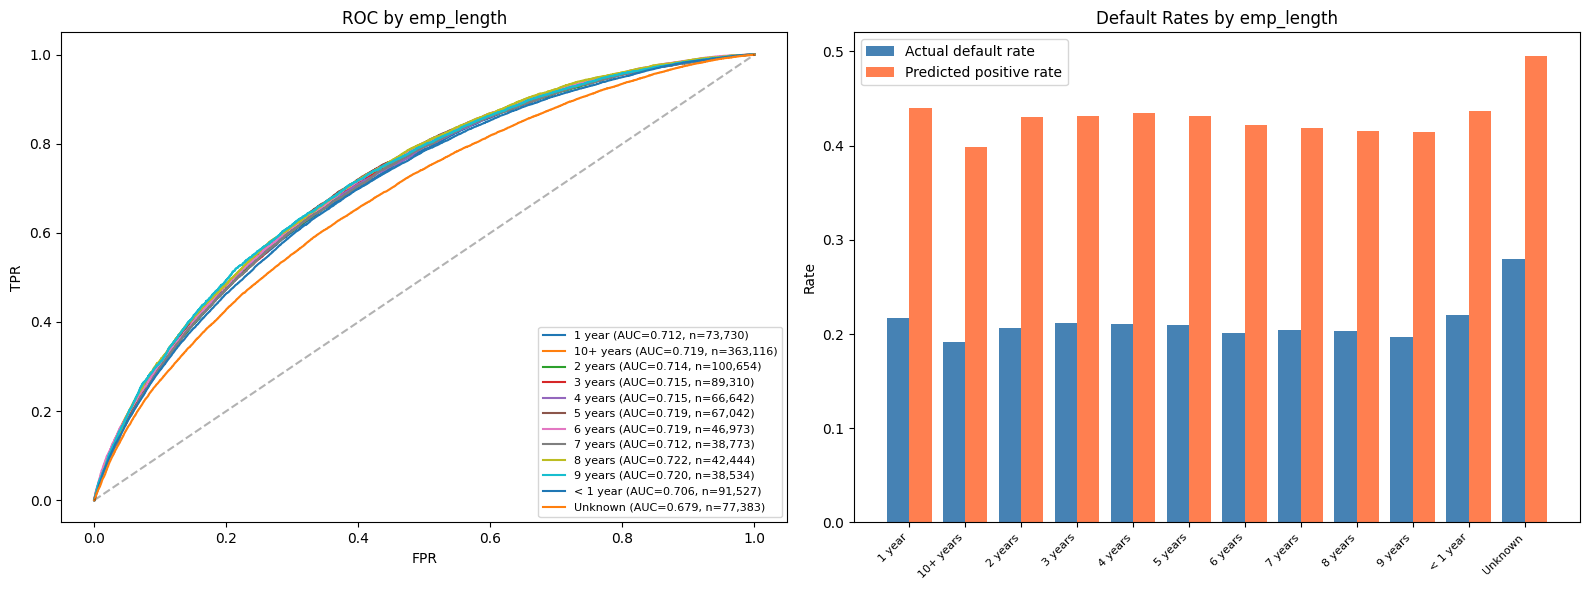


=== Phase 4 Complete ===
Fairness analysis done for 5 attributes.
Informative attributes: ['income_bracket', 'home_ownership', 'dti_bracket', 'purpose', 'emp_length']
Results saved to reports/fairness_*.csv and reports/fairness_*.png


In [7]:
# Per-group ROC curves for informative attributes
for attr_name in informative:
    attr_vals = candidates[attr_name]
    groups = sorted(attr_vals.unique())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ROC per group
    ax = axes[0]
    for g in groups:
        mask = attr_vals.values == g
        if mask.sum() < 50:
            continue
        fpr_g, tpr_g, _ = roc_curve(y_test.values[mask], y_prob[mask])
        auroc_g = roc_auc_score(y_test.values[mask], y_prob[mask])
        ax.plot(fpr_g, tpr_g, label=f"{g} (AUC={auroc_g:.3f}, n={mask.sum():,})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC by {attr_name}"); ax.legend(fontsize=8)

    # Positive prediction rate per group
    ax = axes[1]
    pred_rates = []
    true_rates = []
    group_labels = []
    for g in groups:
        mask = attr_vals.values == g
        if mask.sum() < 50:
            continue
        pred_rates.append(y_pred[mask].mean())
        true_rates.append(y_test.values[mask].mean())
        group_labels.append(f"{g}")
    x = np.arange(len(group_labels))
    ax.bar(x - 0.2, true_rates, 0.4, label="Actual default rate", color="steelblue")
    ax.bar(x + 0.2, pred_rates, 0.4, label="Predicted positive rate", color="coral")
    ax.set_xticks(x); ax.set_xticklabels(group_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Default Rates by {attr_name}"); ax.legend()
    ax.set_ylabel("Rate")

    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, f"fairness_{attr_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Save fairness results
summary.to_csv(os.path.join(REPORTS_DIR, "fairness_summary.csv"))
proxy_df.to_csv(os.path.join(REPORTS_DIR, "proxy_leakage.csv"))

print("\n=== Phase 4 Complete ===")
print(f"Fairness analysis done for {len(candidates)} attributes.")
print(f"Informative attributes: {informative}")
print(f"Results saved to reports/fairness_*.csv and reports/fairness_*.png")

## 4.7 Justified vs Unjustified Disparities

A disparity is **justified** if the model's different treatment reflects actual differences in default rates. It is **unjustified** if the model treats groups differently even after accounting for their true risk.

We measure this by comparing: (1) actual default rate per group, (2) predicted positive rate per group, and (3) the calibration gap = |predicted rate - actual rate| per group. If the model is well-calibrated across groups, disparities are justified. If some groups have larger calibration gaps, the model may be systematically biased against them.

In [8]:
# Justified vs Unjustified disparity analysis
calibration_results = {}

for attr_name in informative:
    attr_vals = candidates[attr_name]
    groups = sorted(attr_vals.unique())
    rows = []
    for g in groups:
        mask = attr_vals.values == g
        if mask.sum() < 50:
            continue
        actual_rate = y_test.values[mask].mean()
        pred_rate = y_pred[mask].mean()
        auroc_g = roc_auc_score(y_test.values[mask], y_prob[mask])
        gap = pred_rate - actual_rate
        rows.append({
            "Group": g,
            "N": mask.sum(),
            "Actual Default %": round(actual_rate * 100, 1),
            "Predicted Positive %": round(pred_rate * 100, 1),
            "Gap (pp)": round(gap * 100, 1),
            "AUROC": round(auroc_g, 3),
        })
    calibration_results[attr_name] = pd.DataFrame(rows)

# Display each attribute
for attr_name, df_cal in calibration_results.items():
    print(f"\n{'='*60}")
    print(f"  {attr_name.upper()}")
    print(f"{'='*60}")
    print(df_cal.to_string(index=False))
    
    max_gap = df_cal["Gap (pp)"].abs().max()
    min_auroc = df_cal["AUROC"].min()
    max_auroc = df_cal["AUROC"].max()
    
    if max_gap <= 3:
        print(f"  → JUSTIFIED: Max calibration gap {max_gap}pp — model tracks actual rates well")
    elif max_gap <= 8:
        print(f"  → PARTIALLY JUSTIFIED: Max calibration gap {max_gap}pp — some bias present")
    else:
        print(f"  → UNJUSTIFIED: Max calibration gap {max_gap}pp — systematic bias detected")
    
    if max_auroc - min_auroc > 0.05:
        print(f"  → PERFORMANCE GAP: AUROC ranges {min_auroc:.3f}–{max_auroc:.3f} — model works better for some groups")


  INCOME_BRACKET
Group      N  Actual Default %  Predicted Positive %  Gap (pp)  AUROC
 High 363870              18.0                  31.0      13.0  0.724
  Low 365376              23.4                  53.8      30.4  0.695
  Mid 366882              21.2                  42.4      21.2  0.718
  → UNJUSTIFIED: Max calibration gap 30.4pp — systematic bias detected

  HOME_OWNERSHIP
   Group      N  Actual Default %  Predicted Positive %  Gap (pp)  AUROC
     ANY    621              19.0                  38.8      19.8  0.725
MORTGAGE 533866              17.9                  37.1      19.2  0.716
     OWN 131056              21.2                  44.4      23.2  0.695
    RENT 430581              24.5                  48.3      23.9  0.709
  → UNJUSTIFIED: Max calibration gap 23.9pp — systematic bias detected

  DTI_BRACKET
Group      N  Actual Default %  Predicted Positive %  Gap (pp)  AUROC
 High 365014              25.4                  59.4      34.0  0.699
  Low 365639          

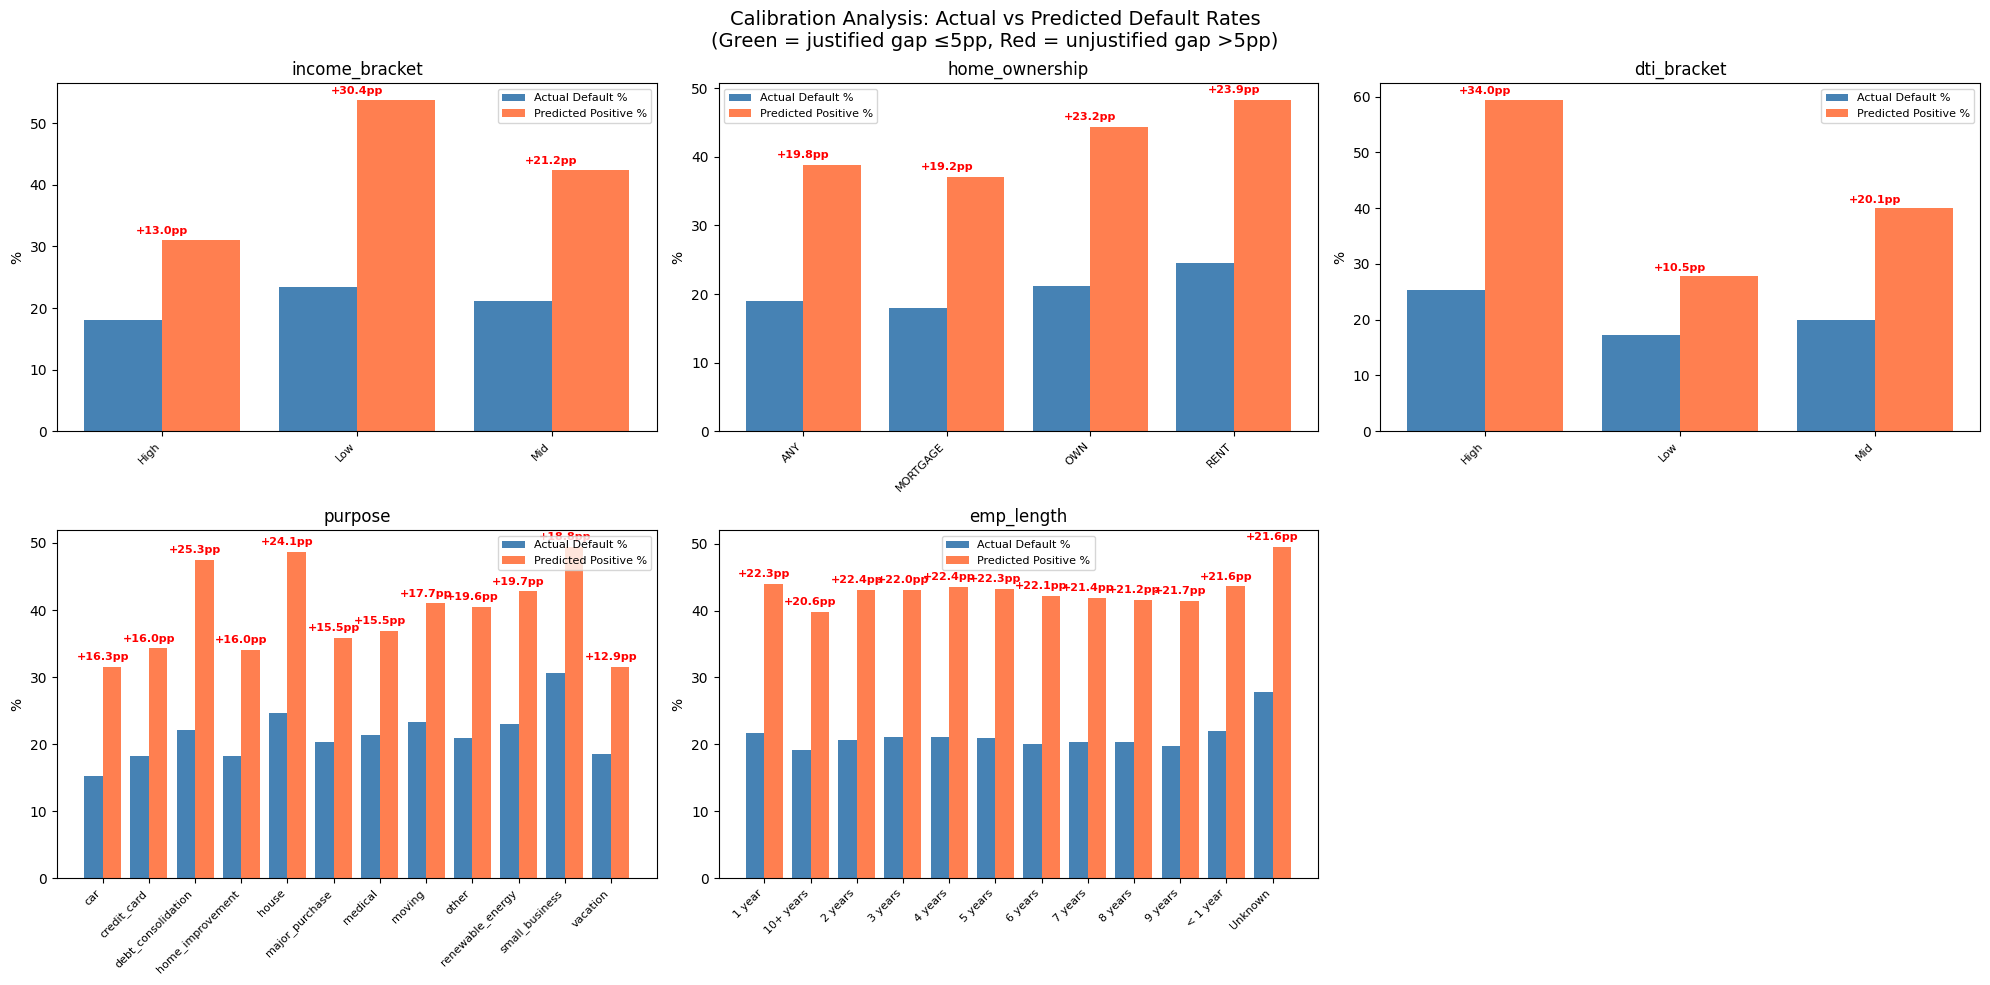


=== Fairness Verdict ===
  income_bracket: max gap=30.4pp → UNJUSTIFIED
  home_ownership: max gap=23.9pp → UNJUSTIFIED
  dti_bracket: max gap=34.0pp → UNJUSTIFIED
  purpose: max gap=25.3pp → UNJUSTIFIED
  emp_length: max gap=22.4pp → UNJUSTIFIED

Saved calibration_analysis.csv


In [9]:
# Visualization: calibration gap per group for all attributes
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, attr_name in enumerate(informative):
    ax = axes[i]
    df_cal = calibration_results[attr_name]
    
    x = np.arange(len(df_cal))
    ax.bar(x - 0.2, df_cal["Actual Default %"], 0.4, label="Actual Default %", color="steelblue")
    ax.bar(x + 0.2, df_cal["Predicted Positive %"], 0.4, label="Predicted Positive %", color="coral")
    
    # Annotate gaps
    for j, row in df_cal.iterrows():
        gap = row["Gap (pp)"]
        color = "red" if abs(gap) > 5 else "green"
        y_pos = max(row["Actual Default %"], row["Predicted Positive %"]) + 1
        ax.annotate(f"{gap:+.1f}pp", (j, y_pos), ha="center", fontsize=8, color=color, weight="bold")
    
    ax.set_xticks(x)
    ax.set_xticklabels(df_cal["Group"], rotation=45, ha="right", fontsize=8)
    ax.set_title(attr_name, fontsize=12)
    ax.set_ylabel("%")
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(informative), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Calibration Analysis: Actual vs Predicted Default Rates\n(Green = justified gap ≤5pp, Red = unjustified gap >5pp)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "calibration_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

# Summary verdict
print("\n=== Fairness Verdict ===")
for attr_name, df_cal in calibration_results.items():
    max_gap = df_cal["Gap (pp)"].abs().max()
    verdict = "JUSTIFIED" if max_gap <= 3 else "PARTIALLY JUSTIFIED" if max_gap <= 8 else "UNJUSTIFIED"
    print(f"  {attr_name}: max gap={max_gap}pp → {verdict}")

# Save calibration results
all_cal = pd.concat({k: v for k, v in calibration_results.items()})
all_cal.to_csv(os.path.join(REPORTS_DIR, "calibration_analysis.csv"))
print("\nSaved calibration_analysis.csv")

## 4.8 Threshold Sensitivity Analysis

The over-prediction above comes from the aggressive Youden threshold (0.159). Here we test how different thresholds affect calibration gaps and fairness. A higher threshold reduces false positives but misses more true defaults.

In [10]:
from sklearn.metrics import f1_score, balanced_accuracy_score
from src.fairness import compute_fairness_metrics

# Test a range of thresholds
test_thresholds = np.arange(0.10, 0.55, 0.05)

# Track: overall metrics + calibration gaps + fairness metrics per threshold
threshold_analysis = []

for t in test_thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    pred_rate = y_pred_t.mean()
    actual_rate = y_test.mean()
    
    row = {
        "Threshold": round(t, 2),
        "Pred Positive %": round(pred_rate * 100, 1),
        "Actual Positive %": round(actual_rate * 100, 1),
        "Overall Gap (pp)": round((pred_rate - actual_rate) * 100, 1),
        "F1": round(f1_score(y_test, y_pred_t), 4),
        "Balanced Acc": round(balanced_accuracy_score(y_test, y_pred_t), 4),
    }
    
    # Calibration gap for income_bracket (most policy-relevant)
    for label in ["Low", "Mid", "High"]:
        mask = candidates["income_bracket"].values == label
        grp_pred = y_pred_t[mask].mean()
        grp_actual = y_test.values[mask].mean()
        row[f"Gap_{label}_Inc (pp)"] = round((grp_pred - grp_actual) * 100, 1)
    
    # Demographic parity diff for income_bracket
    try:
        fm = compute_fairness_metrics(y_test.values, y_pred_t, candidates["income_bracket"].values)
        row["DPD_income"] = round(fm["demographic_parity_diff"], 4)
    except:
        row["DPD_income"] = np.nan
    
    threshold_analysis.append(row)

ta = pd.DataFrame(threshold_analysis)
print("=== Threshold Sensitivity Analysis ===")
print(ta.to_string(index=False))

=== Threshold Sensitivity Analysis ===
 Threshold  Pred Positive %  Actual Positive %  Overall Gap (pp)     F1  Balanced Acc  Gap_Low_Inc (pp)  Gap_Mid_Inc (pp)  Gap_High_Inc (pp)  DPD_income
      0.10             67.4               20.9              46.5 0.4126        0.6254              56.8              46.1               36.6      0.2569
      0.15             45.9               20.9              25.1 0.4401        0.6548              34.5              24.6               16.1      0.2383
      0.20             30.1               20.9               9.2 0.4359        0.6461              15.5               9.4                2.7      0.1817
      0.25             19.3               20.9              -1.6 0.3994        0.6210               1.9              -1.1               -5.6      0.1290
      0.30             12.3               20.9              -8.6 0.3393        0.5927              -7.2              -8.0              -10.7      0.0891
      0.35              7.7               2

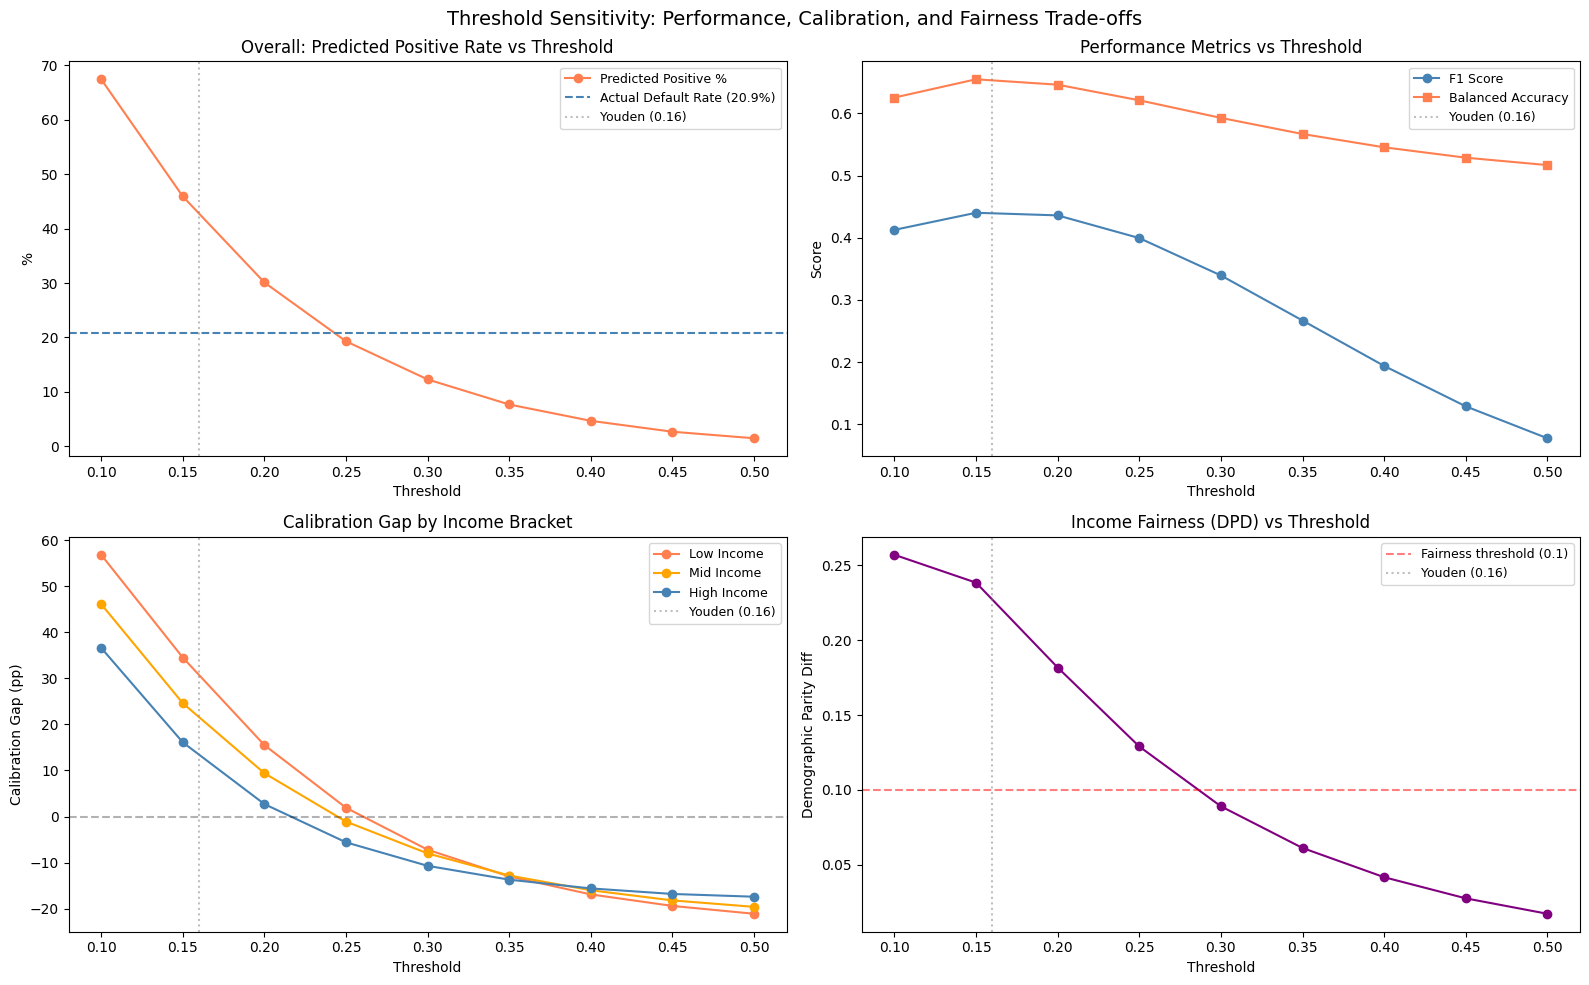


Best calibrated threshold: 0.25
  Overall gap: -1.6pp
  F1: 0.3994, Balanced Acc: 0.621
  Income DPD: 0.129

Youden (t≈0.16): F1=0.4401, Gap=25.1pp, DPD=0.2383
Calibrated (t=0.25): F1=0.3994, Gap=-1.6pp, DPD=0.129

Conclusion: Higher thresholds reduce calibration gaps and fairness disparities,
but at the cost of lower recall (missing more true defaults).
Saved threshold_sensitivity.csv


In [11]:
# Visualization: 4-panel threshold sensitivity
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Predicted vs Actual rate
ax = axes[0, 0]
ax.plot(ta["Threshold"], ta["Pred Positive %"], "o-", color="coral", label="Predicted Positive %")
ax.axhline(y=ta["Actual Positive %"].iloc[0], color="steelblue", linestyle="--", label=f"Actual Default Rate ({ta['Actual Positive %'].iloc[0]}%)")
ax.axvline(x=0.16, color="gray", linestyle=":", alpha=0.5, label="Youden (0.16)")
ax.set_xlabel("Threshold"); ax.set_ylabel("%")
ax.set_title("Overall: Predicted Positive Rate vs Threshold")
ax.legend(fontsize=9)

# Panel 2: F1 and Balanced Accuracy
ax = axes[0, 1]
ax.plot(ta["Threshold"], ta["F1"], "o-", color="steelblue", label="F1 Score")
ax.plot(ta["Threshold"], ta["Balanced Acc"], "s-", color="coral", label="Balanced Accuracy")
ax.axvline(x=0.16, color="gray", linestyle=":", alpha=0.5, label="Youden (0.16)")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Performance Metrics vs Threshold")
ax.legend(fontsize=9)

# Panel 3: Calibration gap by income group
ax = axes[1, 0]
for label, color in [("Low", "coral"), ("Mid", "orange"), ("High", "steelblue")]:
    ax.plot(ta["Threshold"], ta[f"Gap_{label}_Inc (pp)"], "o-", color=color, label=f"{label} Income")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax.axvline(x=0.16, color="gray", linestyle=":", alpha=0.5, label="Youden (0.16)")
ax.set_xlabel("Threshold"); ax.set_ylabel("Calibration Gap (pp)")
ax.set_title("Calibration Gap by Income Bracket")
ax.legend(fontsize=9)

# Panel 4: Demographic Parity Diff (income)
ax = axes[1, 1]
ax.plot(ta["Threshold"], ta["DPD_income"], "o-", color="purple")
ax.axhline(y=0.1, color="red", linestyle="--", alpha=0.5, label="Fairness threshold (0.1)")
ax.axvline(x=0.16, color="gray", linestyle=":", alpha=0.5, label="Youden (0.16)")
ax.set_xlabel("Threshold"); ax.set_ylabel("Demographic Parity Diff")
ax.set_title("Income Fairness (DPD) vs Threshold")
ax.legend(fontsize=9)

plt.suptitle("Threshold Sensitivity: Performance, Calibration, and Fairness Trade-offs", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "threshold_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show()

# Find the "sweet spot" — threshold where overall gap is closest to 0
best_cal_idx = ta["Overall Gap (pp)"].abs().idxmin()
best_cal = ta.iloc[best_cal_idx]
print(f"\nBest calibrated threshold: {best_cal['Threshold']}")
print(f"  Overall gap: {best_cal['Overall Gap (pp)']}pp")
print(f"  F1: {best_cal['F1']}, Balanced Acc: {best_cal['Balanced Acc']}")
print(f"  Income DPD: {best_cal['DPD_income']}")

# Compare Youden vs calibrated
youden_row = ta[ta["Threshold"] == 0.15].iloc[0] if 0.15 in ta["Threshold"].values else ta.iloc[0]
print(f"\nYouden (t≈0.16): F1={youden_row['F1']}, Gap={youden_row['Overall Gap (pp)']}pp, DPD={youden_row['DPD_income']}")
print(f"Calibrated (t={best_cal['Threshold']}): F1={best_cal['F1']}, Gap={best_cal['Overall Gap (pp)']}pp, DPD={best_cal['DPD_income']}")
print(f"\nConclusion: Higher thresholds reduce calibration gaps and fairness disparities,")
print(f"but at the cost of lower recall (missing more true defaults).")

ta.to_csv(os.path.join(REPORTS_DIR, "threshold_sensitivity.csv"), index=False)
print("Saved threshold_sensitivity.csv")